# Model analysis

Loads a checkpoint produced by `decoder/train.py` (`config.json` + `model.pth`)
and plots training/validation loss curves plus validation-set performance.

Set `RUN_DIR` below to the training run you want to inspect, e.g. `"../example_run"`.

In [13]:
import json
import os
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# decoder/ holds model.py and train.py -- reuse them instead of redefining
# the architecture/dataset/split logic here.
sys.path.append(os.path.join("..", "decoder"))
from model import build_model
from train import load_dataset, make_loaders, get_device

In [17]:
# Path to a run directory written by decoder/train.py
# (must contain config.json and model.pth)
RUN_DIR = "../example_run"

with open(os.path.join(RUN_DIR, "config.json")) as f:
    config = json.load(f)
with open(os.path.join(RUN_DIR, "metrics.json")) as f:
    metrics = json.load(f)

print("Config:", json.dumps(config, indent=2))

Config: {
  "hidden_sizes": [
    128,
    64
  ],
  "dropout": [
    0.2,
    0.1
  ],
  "lr": 0.003,
  "dataset_path": "/home/vfairon/Documents/Cours/Q9/Stage/adversarial-blind-spots-in-quantum-error-correction-mlp-decoder/example_run/dataset.npz",
  "seed": 929893137,
  "epochs": 30
}


## Rebuild the model and its validation split

Uses the exact `dataset_path` and `seed` recorded in `config.json`, so this is
the *same* stratified validation split `train.py` evaluated on during training.

In [18]:
device = get_device()
print("Using device:", device)

dataset = load_dataset(config["dataset_path"])
input_size = dataset.features.shape[1]

batch_size = config.get("batch_size", 1024 if device.type == "cuda" else 128)
_, val_loader = make_loaders(dataset, batch_size, config["seed"])

model = build_model(config, input_size).to(device)
model.load_state_dict(torch.load(os.path.join(RUN_DIR, "model.pth"), map_location=device))
model.eval()

print(f"Validation samples: {len(val_loader.dataset)}")

Using device: cuda
Validation samples: 200000


## Training curves

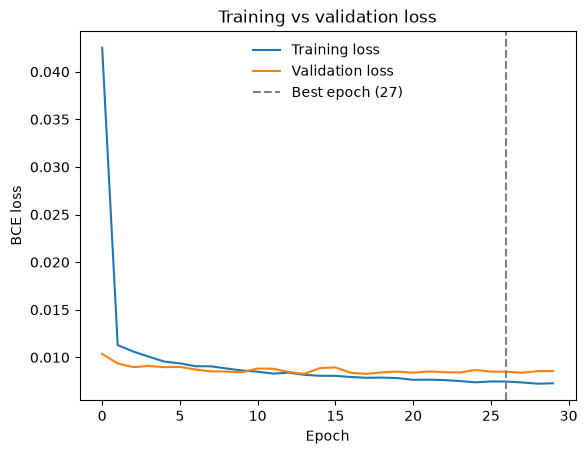

Best validation accuracy: 0.9981 (epoch 27)


In [19]:
plt.figure()
plt.plot(metrics["train_losses"], label="Training loss")
plt.plot(metrics["val_losses"], label="Validation loss")
plt.axvline(metrics["best_epoch"] - 1, color="gray", linestyle="--", label=f'Best epoch ({metrics["best_epoch"]})')
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.legend(frameon=False)
plt.title("Training vs validation loss")
plt.show()

print(f'Best validation accuracy: {metrics["best_val_accuracy"]:.4f} (epoch {metrics["best_epoch"]})')

## Testing on independently generated evaluation sets

Instead of reusing the training dataset's own held-out split, generate several
*new* datasets with the exact same circuit parameters (distance, rounds, noise)
as the training data -- read back from its `.json` -- but a different
random seed each. Evaluating on these checks generalization to shots that were
never part of the original sample at all (not just a split of it), and pools
results across seeds so the estimate isn't tied to one particular draw.

In [20]:
sys.path.append(os.path.join("..", "data"))
from generate_datasets import create_circuit, create_sampler, sample as draw_samples
from mwpm_reference import load_metadata

metadata_path = os.path.splitext(config["dataset_path"])[0] + ".json"
circuit_metadata = load_metadata(metadata_path)
print("Circuit params (same as training data):", circuit_metadata)

circuit = create_circuit(**circuit_metadata)

Circuit params (same as training data): {'distance': 3, 'rounds': 9, 'noise_type': 'depolarizing', 'noise_default': 0.005}
Generating noise constants for noise model: depolarizing with default value: 0.005
########################################################


In [21]:
N_SAMPLES_PER_SEED = 50_000
EVAL_SEEDS = list(range(1000, 1005))  # 5 independent eval sets, distinct from the training seed


def evaluate_on_features(features, labels):
    """Run the model on a (features, labels) pair, returning (probs, preds, logical_error_rate)."""
    with torch.no_grad():
        logits = model(torch.from_numpy(features).to(device)).squeeze(-1)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (logits > 0.0).float().cpu().numpy()
    ler = (preds != labels.reshape(-1)).mean()
    return probs, preds, ler


per_seed_ler = []
all_features, all_labels, all_probs, all_preds = [], [], [], []

for seed in EVAL_SEEDS:
    sampler = create_sampler(circuit, seed=seed)
    seed_labels, seed_features = draw_samples(sampler, N_SAMPLES_PER_SEED)

    probs_s, preds_s, ler_s = evaluate_on_features(seed_features, seed_labels)
    per_seed_ler.append(ler_s)

    all_features.append(seed_features)
    all_labels.append(seed_labels.reshape(-1))
    all_probs.append(probs_s)
    all_preds.append(preds_s)

    print(f"seed={seed}: LER={ler_s:.4%}")

# Pool every seed's shots together for the confusion matrix / histogram /
features_eval = np.concatenate(all_features)
labels_np = np.concatenate(all_labels)
probs = np.concatenate(all_probs)
preds = np.concatenate(all_preds)

logical_error_rate = (preds != labels_np).mean()

print(f"\nMean LER across seeds : {np.mean(per_seed_ler):.4%} (+/- {np.std(per_seed_ler):.4%})")
print(f"Pooled LER (all seeds): {logical_error_rate:.4%}")

seed=1000: LER=0.1920%
seed=1001: LER=0.2000%
seed=1002: LER=0.1780%
seed=1003: LER=0.1700%
seed=1004: LER=0.2020%

Mean LER across seeds : 0.1884% (+/- 0.0125%)
Pooled LER (all seeds): 0.1884%


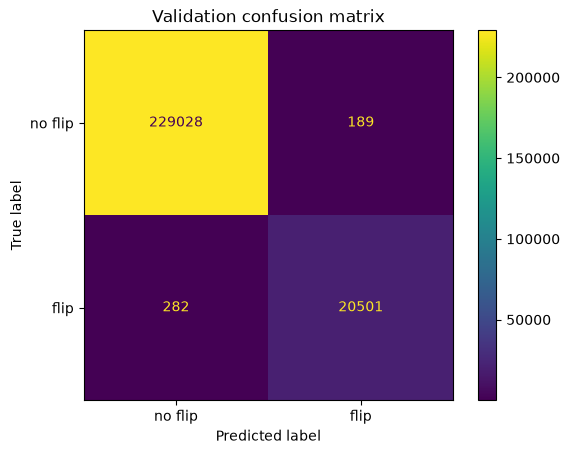

In [22]:
cm = confusion_matrix(labels_np, preds)
ConfusionMatrixDisplay(cm, display_labels=["no flip", "flip"]).plot()
plt.title("Validation confusion matrix")
plt.show()

## Optional: compare against the MWPM baseline

Requires `pymatching` and the dataset's circuit-parameters `.json` sidecar
(the one written by `generate_datasets.py`, e.g. `train_depolarizing.json`
next to `train_depolarizing.npz`).

In [23]:
from mwpm_reference import build_matcher

matcher = build_matcher(circuit)

mwpm_preds = np.asarray(matcher.decode_batch(features_eval)).reshape(-1)
mwpm_ler = (mwpm_preds != labels_np).mean()

print(f"MLP  LER (pooled across seeds) : {logical_error_rate:.4%}")
print(f"MWPM LER (pooled across seeds) : {mwpm_ler:.4%}")

MLP  LER (pooled across seeds) : 0.1884%
MWPM LER (pooled across seeds) : 0.1708%


## Are the MLP and MWPM actually different, or just similarly accurate?

McNemar test which will say if  a significant result
means one decoder is reliably better on the shots where they disagree, not
just luckier overall. The failure overlap (Jaccard) then says how much their
*mistakes* actually coincide.

In [24]:
from scipy.stats import binomtest

y_true = labels_np.astype(bool)
mlp_wrong = (preds.astype(bool) != y_true)
mwpm_wrong = (mwpm_preds.astype(bool) != y_true)

both_right = np.sum(~mlp_wrong & ~mwpm_wrong)
both_wrong = np.sum(mlp_wrong & mwpm_wrong)
b = np.sum(~mlp_wrong & mwpm_wrong)   # MLP right, MWPM wrong
c = np.sum(mlp_wrong & ~mwpm_wrong)   # MLP wrong, MWPM right
n = len(y_true)

print("Contingency table (per-shot outcome, pooled across seeds):")
print(f"  both correct              : {both_right:7d}  ({both_right/n:.4%})")
print(f"  both wrong                : {both_wrong:7d}  ({both_wrong/n:.4%})")
print(f"  MLP right,  MWPM wrong (b): {b:7d}")
print(f"  MLP wrong,  MWPM right (c): {c:7d}")

if b + c > 0:
    p_value = binomtest(b, b + c, 0.5).pvalue
    print(f"\nMcNemar's test: b={b}, c={c}, p-value = {p_value:.4g}")
    if p_value < 0.05:
        winner = "MLP" if b > c else "MWPM"
        print(f"-> Significant at alpha=0.05: {winner} is reliably better on shots where they disagree.")
    else:
        print("-> Not significant at alpha=0.05: no reliable difference on shots where they disagree.")
else:
    print("\nMLP and MWPM never disagreed on any shot -- McNemar's test is undefined.")

union_wrong = np.sum(mlp_wrong | mwpm_wrong)
if union_wrong > 0:
    jaccard = both_wrong / union_wrong
    print(f"Failure overlap (Jaccard) = {jaccard:.4f}  ({both_wrong}/{union_wrong})")

Contingency table (per-shot outcome, pooled across seeds):
  both correct              :  249434  (99.7736%)
  both wrong                :     332  (0.1328%)
  MLP right,  MWPM wrong (b):      95
  MLP wrong,  MWPM right (c):     139

McNemar's test: b=95, c=139, p-value = 0.004833
-> Significant at alpha=0.05: MWPM is reliably better on shots where they disagree.
Failure overlap (Jaccard) = 0.5866  (332/566)
